In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import re
from datetime import datetime
from datetime import date
from scipy.stats import chi2_contingency
import numpy as np
from dateutil.relativedelta import relativedelta
import numpy as np
from scipy.stats import chi2_contingency


# Importa os dados

In [3]:
df = pd.read_excel(
    "dados_atualizado.xlsx",
    sheet_name=0,
    header=1,          # usa a 2ª linha como cabeçalho real
    dtype={"Class. Por idade": str},  # evita converter "1" em número se quiser
)


## Criando Pipeline de Limpeza dos Dados

In [5]:
def limpa_dados(df):
    
    colunas_data = ["data_nascimento","data_primeira_consulta","data_primeira_colonoscopia"]

    def padroniza_colunas(df):
        df.columns = (df.columns.astype(str).str.replace("\n", " ", regex=False).str.replace(r"\s+", " ", regex=True).str.strip())
        return df

    def renomeia_colunas(df):
        df = df.rename(columns={
            "Nome": "nome",
            "Class. Por idade": "classificacao_idade",
            "Data nascimento": "data_nascimento",
            "Data 1ª consulta": "data_primeira_consulta",
            "Tempo entre início dos sintomas e primeira consulta": "intervalo_sintomas_primeira_consulta",
            "Sexo": "sexo",
            "Tipo": "tipo",
            "Perda de peso": "perda_peso",
            "Idade (meses) início dos sintomas": "intervalo_nascimento_sintomas",
            "Data 1ª colono": "data_primeira_colonoscopia",
            "Unnamed: 10": "intervalo_sintomas_primeira_colonoscopia",
            "Classificação": "diagnostico",
        })
        return df

    def formata_colunas_data(df):
        for coluna in colunas_data:
            df[coluna] = (pd.to_datetime(df[coluna], errors="coerce").dt.strftime("%d/%m/%Y"))
        return df

    def deixar_coluna_inteira(df, coluna):
        for index, tempo in enumerate(df[coluna].tolist()):
            if tempo != '?':
                numero = int(re.sub(r"\D", "", tempo))
                df.loc[index, coluna] = numero
            elif tempo == "?":
                df.loc[index, coluna] = -1
            df[coluna] = pd.to_numeric(df[coluna], errors="coerce")
            df[coluna] = df[coluna].astype("Int64")
        return df

        
    def criar_coluna(df, coluna):
        datas = pd.to_datetime(df['data_nascimento'],format="%d/%m/%Y",errors="coerce")
        meses = df["intervalo_nascimento_sintomas"]
        df[coluna] = [d + pd.DateOffset(months=int(m)) if pd.notna(d) and pd.notna(m) else pd.NaT for d, m in zip(datas, meses)  ]
        df[coluna] = (pd.to_datetime(df[coluna],errors="coerce" ).dt.strftime("%d/%m/%Y") )
        return df

    

    def ajustar_coluna_tipo(df):
        for index, tipo in enumerate(df['tipo'].tolist()):
            if tipo== 'Diarreia ':
                  df.loc[index, "tipo"] = 'Diarreia'
            
        return df
        
    def padronizar_sim_nao(df):
        for index, resposta in enumerate(df['perda_peso'].tolist()):
            if resposta == "não" or resposta == 'Não':
                  df.loc[index, "perda_peso"] = 'N'
            else:
                df.loc[index, "perda_peso"] = 'S'
        return df   


    def calcula_intervalo_colonoscopia(df):
        resultados = []
        for index in range(len(df)):
            d1_str = df.loc[index, "data_inicio_sintomas"]
            d2_str = df.loc[index, "data_primeira_colonoscopia"]
            # 1) converte para datetime
            try:
                d1 = datetime.strptime(d1_str, "%d/%m/%Y")
                d2 = datetime.strptime(d2_str, "%d/%m/%Y")
            except (ValueError, TypeError):
                resultados.append(None)
                continue
            # 2) valida ordem
            if d2 <= d1:
                resultados.append(None)
                continue
            # 3) calcula meses completos
            meses = ((d2.year - d1.year) * 12 + (d2.month - d1.month) - (d2.day < d1.day))

            resultados.append(meses)

        df["intervalo_sintomas_primeira_colonoscopia_recalculado"] = resultados
        df["intervalo_sintomas_primeira_colonoscopia_recalculado"] = pd.to_numeric(df["intervalo_sintomas_primeira_colonoscopia_recalculado"],errors="coerce")
        df["intervalo_sintomas_primeira_colonoscopia_recalculado"] = df["intervalo_sintomas_primeira_colonoscopia_recalculado"].astype("Int64")

        return df


    df = df.drop(index=0).reset_index(drop=True)
    df = padroniza_colunas(df)
    df = renomeia_colunas(df)
    df = formata_colunas_data(df)
    df = df.drop(columns=["nome"])
    df = deixar_coluna_inteira(df,"intervalo_sintomas_primeira_consulta")
    df = deixar_coluna_inteira(df,"intervalo_sintomas_primeira_colonoscopia")
    df = criar_coluna(df,"data_inicio_sintomas")  
    df = calcula_intervalo_colonoscopia(df)
    df = padronizar_sim_nao(df)
    df = ajustar_coluna_tipo(df)

    return df

In [7]:
dados_df = limpa_dados(df)
dados_df = dados_df[dados_df["intervalo_sintomas_primeira_consulta"]!=-1]

## Quebra o dataset por sexo

In [9]:
dados_df.head(2)

,classificacao_idade,data_nascimento,data_primeira_consulta,intervalo_sintomas_primeira_consulta,sexo,tipo,perda_peso,intervalo_nascimento_sintomas,data_primeira_colonoscopia,intervalo_sintomas_primeira_colonoscopia,diagnostico,data_inicio_sintomas,intervalo_sintomas_primeira_colonoscopia_recalculado
0,VEOIBD,27/09/2013,02/03/2023,54,F,Enterorragia,N,60,15/07/2019,9,CU,27/09/2018,9
1,VEOIBD,25/10/2024,09/06/2026,5,F,Enterorragia,N,14,20/05/2026,4,CNC,25/12/2025,4


In [17]:
dados_df['diagnostico'].unique()

array(['CU', 'CNC', 'DC'], dtype=object)

In [13]:
mulheres_df = dados_df[dados_df['sexo'] == 'F'].drop(columns=["sexo"])

homens_df = dados_df[dados_df['sexo'] == 'M'].drop(columns=["sexo"])

total_mulheres = len(mulheres_df)

total_mulheres = len(homens_df)

# Analise Bivariada.

In [52]:
# Analise de associacao entre : SEXO X DIAGNOSTICO
tabela_sexo_diagnostico = pd.crosstab(
    dados_df["diagnostico"],
    dados_df["sexo"],
    margins=True,
    margins_name='Total'
)
tabela_sexo_diagnostico

sexo,F,M,Total
diagnostico,,,
CNC,9,8,17
CU,15,17,32
DC,20,31,51
Total,44,56,100


In [54]:
# Construindo a tabela com os valores esperados

# Eij = (Total linha i) x (Total coluna j) / Total Geral (44)


# Chi-quadrado → devolve esperados
chi2, p, dof, esp = chi2_contingency(tabela_sexo_diagnostico)

# Converte esperados em DataFrame com mesmos índices/colunas
tabela_esperada_s_d_df = pd.DataFrame(esp, index=tabela_sexo_diagnostico.index, columns=tabela_sexo_diagnostico.columns)

tabela_esperada_s_d_df.round(2)

sexo,F,M,Total
diagnostico,,,
CNC,7.48,9.52,17.0
CU,14.08,17.92,32.0
DC,22.44,28.56,51.0
Total,44.00,56.00,100.0


In [58]:
# Resíduos padronizados ajustados (Pearson)
resid_s_d = (tabela_sexo_diagnostico - tabela_esperada_s_d_df) / np.sqrt(tabela_esperada_s_d_df)
resid_s_d = resid_s_d.drop(columns=["Total"])
resid_s_d = resid_s_d[:-1]
resid_s_d.round(2)

sexo,F,M
diagnostico,,
CNC,0.56,-0.49
CU,0.25,-0.22
DC,-0.52,0.46


In [85]:
# Pensando depois pode ser uma lista de parametros que ela recebe 
# Lista de categorias
def create_table(categoria1,categoria2):
    tres_df = []
    tabela_c1_c2 = pd.crosstab(
        categoria1,
        categoria2,
        margins=True,
        margins_name='Total'
    )
    tres_df.append(tabela_c1_c2)
    chi2, p, dof, esp = chi2_contingency(tabela_c1_c2)
   
    tabela_esperada_c1_c2_df = pd.DataFrame(esp, index=tabela_c1_c2.index, columns=tabela_c1_c2.columns)
    tres_df.append(tabela_esperada_c1_c2_df)

    # Resíduos padronizados ajustados (Pearson)
    resid_c1_c2 = (tabela_c1_c2 - tabela_esperada_c1_c2_df) / np.sqrt(tabela_esperada_c1_c2_df)
    resid_c1_c2 = resid_c1_c2.drop(columns=["Total"])
    resid_c1_c2 = resid_c1_c2[:-1]
    resid_c1_c2.round(2)

    tres_df.append(resid_c1_c2)
    # print(tres_df)
    return tres_df

In [ ]:
## Criar uma funcao que me retorna 3 df`s
# OSS

teste = create_table(dados_df["diagnostico"],
    dados_df["sexo"])
for i in teste : 
    print(i)

# Criacao da  CONSTANTE colunas_nao_categoricas

In [19]:
colunas_nao_categoricas = [
    "data_nascimento",
    "data_primeira_consulta",
    "intervalo_sintomas_primeira_consulta", 
    "intervalo_nascimento_sintomas", 
    "data_primeira_colonoscopia",  
    "intervalo_sintomas_primeira_colonoscopia",    
    "data_inicio_sintomas",    
    "intervalo_sintomas_primeira_colonoscopia_recalculado"
]

In [13]:
# mulheres_df.head()
# mulheres_df[['data_nascimento','intervalo_nascimento_sintomas','data_inicio_sintomas']].head()

,classificacao_idade,data_nascimento,data_primeira_consulta,intervalo_sintomas_primeira_consulta,tipo,perda_peso,intervalo_nascimento_sintomas,data_primeira_colonoscopia,intervalo_sintomas_primeira_colonoscopia,classificacao,data_inicio_sintomas,intervalo_sintomas_primeira_colonoscopia_recalculado
0,VEOIBD,27/09/2013,02/03/2023,54,Enterorragia,N,60,15/07/2019,9,CU,27/09/2018,9
1,VEOIBD,25/10/2024,09/06/2026,5,Enterorragia,N,14,20/05/2026,4,CNC,25/12/2025,4
2,DI Ped,01/01/2006,04/05/2021,13,Dor abdominal,N,168,13/04/2020,3,DC,01/01/2020,3
3,VEOIBD,19/04/2019,03/08/2023,34,Diarreia,N,18,01/05/2022,18,CNC,19/10/2020,18
4,Início precoce,18/05/2012,19/01/2023,20,Febre,S,108,26/01/2023,20,DC,18/05/2021,20


# Algumas estatisticas descritivas sobre a coluna intervalo_nascimento_sintomas

In [21]:
round(pd.Series(mulheres_df["intervalo_nascimento_sintomas"].tolist()).describe(),2)

count     44.00
mean      80.23
std       53.66
min        3.00
25%       35.25
50%       69.00
75%      132.75
max      175.00
dtype: float64

# Algumas estatisticas descritivas sobre a coluna intervalo_sintomas_primeira_colonoscopia

In [23]:
round(pd.Series(mulheres_df["intervalo_sintomas_primeira_colonoscopia"].tolist()).describe(),2)

count    44.00
mean     13.23
std      16.16
min       1.00
25%       3.75
50%       8.00
75%      15.75
max      76.00
dtype: float64

In [25]:
mulheres_colunas_categoricas_df = mulheres_df.drop(columns=colunas_nao_categoricas)
mulheres_colunas_categoricas_df

,classificacao_idade,tipo,perda_peso,diagnostico
0,VEOIBD,Enterorragia,N,CU
1,VEOIBD,Enterorragia,N,CNC
2,DI Ped,Dor abdominal,N,DC
3,VEOIBD,Diarreia,N,CNC
4,Início precoce,Febre,S,DC
5,VEOIBD,Enterorragia,N,CU
7,DI Ped,Diarreia,S,DC
11,DI Ped,Dor abdominal,S,DC
12,DI Ped,Dor abdominal,N,DC
17,DI Ped,Diarreia,S,CNC


In [19]:
# classificacao_idade  = ['VEOIBD ', 'VEOIBD', 'DI Ped', 'Início precoce']

# tipo  = [
# 'Enterorragia',
# 'Dor abdominal',
# 'Diarreia',
# 'Febre',
# 'Perda ponderal',
# 'Hematoquezia', 
# 'Desaceleração do crescim.'
# ]


# perda_peso = ['N','S'] # Virou S ou N

# classificacao = ['CU', 'CNC', 'DC']

In [81]:
# A mesma coisa porem de jeitos diferentes

# mulheres_df[(mulheres_df['tipo']=='Diarreia') & (mulheres_df['perda_peso'] == 'S')]

pd.crosstab(
    mulheres_colunas_categoricas_df["classificacao"],
    mulheres_colunas_categoricas_df["classificacao_idade"],
    margins=True,
    margins_name='Total'
)

classificacao_idade,DI Ped,Início precoce,VEOIBD,VEOIBD,Total
classificacao,,,,,
CNC,1,2,3,3,9
CU,4,2,4,5,15
DC,9,3,4,4,20
Total,14,7,11,12,44


In [75]:
# resultado = df[(df['idade'] > 30) & (df['cidade'] == 'São Paulo')]
tabela_idade = pd.crosstab(
    mulheres_colunas_categoricas_df['classificacao_idade'],
    mulheres_colunas_categoricas_df['classificacao'],
    margins=True,
    margins_name='Total'
)
tabela_idade

classificacao,CNC,CU,DC,Total
classificacao_idade,,,,
DI Ped,1,4,9,14
Início precoce,2,2,3,7
VEOIBD,3,4,4,11
VEOIBD,3,5,4,12
Total,9,15,20,44


In [22]:
tabela_observada = pd.crosstab(mulheres_colunas_categoricas_df['tipo'], mulheres_colunas_categoricas_df['classificacao'], margins=True)
tabela_observada

classificacao,CNC,CU,DC,All
tipo,,,,
Desaceleração do crescim.,0,0,1,1
Diarreia,4,4,11,19
Dor abdominal,0,2,5,7
Enterorragia,4,7,1,12
Febre,0,0,1,1
Hematoquezia,1,1,1,3
Perda ponderal,0,1,0,1
All,9,15,20,44


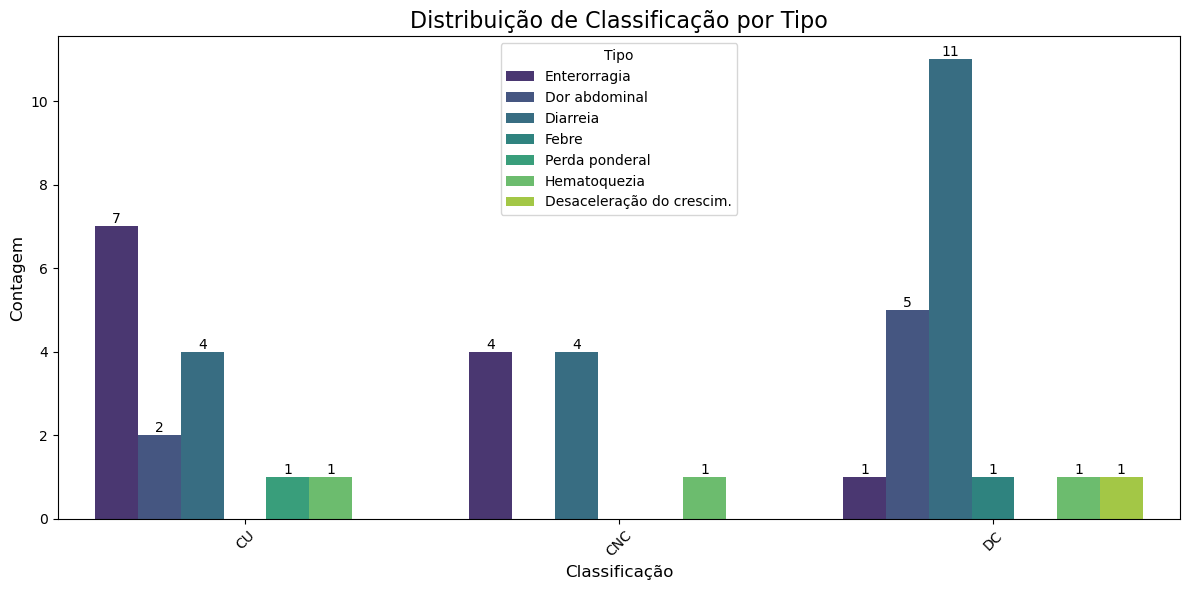

In [85]:
# Configuração para deixar o gráfico maior e mais legível
plt.figure(figsize=(12, 6))

# Criar o gráfico de barras
# 'hue' cria as cores separadas por tipo
ax = sns.countplot(data= mulheres_colunas_categoricas_df, 
                   x='classificacao', 
                   hue='tipo', 
                   palette='viridis')

# Adicionar os números em cima das barras (opcional, mas ajuda muito)
for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribuição de Classificação por Tipo', fontsize=16)
plt.xlabel('Classificação', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.xticks(rotation=45) # Rotaciona os nomes se forem grandes
plt.legend(title='Tipo')
plt.tight_layout()
plt.show()

In [23]:
# Construindo a tabela com os valores esperados

# Eij = (Total linha i) x (Total coluna j) / Total Geral (44)


# Chi-quadrado → devolve esperados
chi2, p, dof, esp = chi2_contingency(tabela_observada)

# Converte esperados em DataFrame com mesmos índices/colunas
esp_df = pd.DataFrame(esp, index=tabela_observada.index, columns=tabela_observada.columns)

esp_df.round(2)

classificacao,CNC,CU,DC,All
tipo,,,,
Desaceleração do crescim.,0.20,0.34,0.45,1.0
Diarreia,3.89,6.48,8.64,19.0
Dor abdominal,1.43,2.39,3.18,7.0
Enterorragia,2.45,4.09,5.45,12.0
Febre,0.20,0.34,0.45,1.0
Hematoquezia,0.61,1.02,1.36,3.0
Perda ponderal,0.20,0.34,0.45,1.0
All,9.00,15.00,20.00,44.0


In [24]:
# tab = pd.crosstab(mulheres_colunas_categoricas_df['tipo'], mulheres_colunas_categoricas_df['classificacao'])
chi2, p, dof, tabela_esp = chi2_contingency(tabela_observada)

# Rij = (Oij - Eij) / sqrt(Eij)

# Resíduos padronizados ajustados (Pearson)
resid = (tabela_observada - tabela_esp) / np.sqrt(tabela_esp)
resid = resid.drop(columns=["All"])
resid = resid[:-1]
resid.round(2)

classificacao,CNC,CU,DC
tipo,,,
Desaceleração do crescim.,-0.45,-0.58,0.81
Diarreia,0.06,-0.97,0.80
Dor abdominal,-1.20,-0.25,1.02
Enterorragia,0.99,1.44,-1.91
Febre,-0.45,-0.58,0.81
Hematoquezia,0.49,-0.02,-0.31
Perda ponderal,-0.45,1.13,-0.67


In [ ]:
# clafissicacao_idade x diagnostico


In [68]:
# Trazer mais graficos testes 

In [25]:

print(f"χ² = {chi2:.2f}")
print(f"gl = {dof}")
print(f"p  = {p:.4f}")

χ² = 15.48
gl = 21
p  = 0.7979


In [26]:
 # Regra de decisão:
# ∣r∣ ≥ 1,96 => significativo (p < 0,05)
# O resíduo padronizado de Pearson segue,
# aproximadamente, uma distribuição normal padrão (média 0, desvio padrão 1):
# se isso é verdade, então podemos usar a tabela da normal padrão (ou a função de distribuição acumulada) 
# para decidir se um valor de r é "grande demais" para ser fruto do acaso.

In [27]:
cenarios = (
    mulheres_colunas_categoricas_df
    .groupby([
        "classificacao_idade",
        "tipo",
        "perda_peso",
        "classificacao"
    ])
    .size()
    .reset_index(name="quantidade")
    .sort_values("quantidade", ascending=False)
)

# cenarios

,classificacao_idade,tipo,perda_peso,classificacao,quantidade
29,VEOIBD,Enterorragia,N,CU,4
1,DI Ped,Diarreia,N,DC,3
25,VEOIBD,Diarreia,N,CNC,2
17,VEOIBD,Enterorragia,N,CNC,2
4,DI Ped,Diarreia,S,DC,2
16,VEOIBD,Diarreia,S,DC,2
6,DI Ped,Dor abdominal,N,DC,2
7,DI Ped,Dor abdominal,S,DC,2
26,VEOIBD,Diarreia,N,DC,2
10,Início precoce,Diarreia,S,CU,2


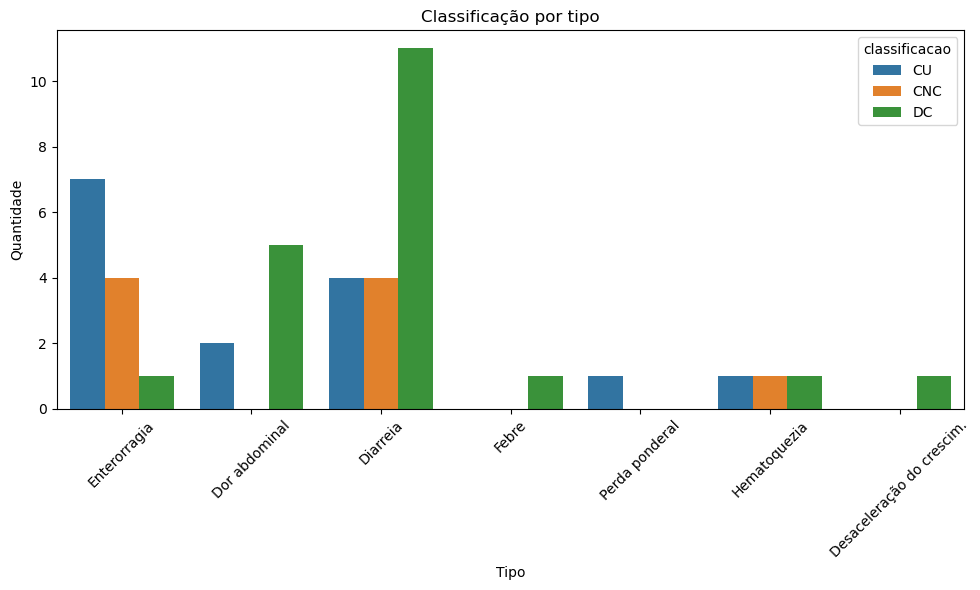

In [28]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=mulheres_colunas_categoricas_df,
    x="tipo",
    hue="classificacao"
)

plt.xticks(rotation=45)
plt.xlabel("Tipo")
plt.ylabel("Quantidade")
plt.title("Classificação por tipo")
plt.tight_layout()

plt.show()

In [29]:
ct = pd.crosstab(
    [
        mulheres_colunas_categoricas_df["classificacao_idade"],
        mulheres_colunas_categoricas_df["tipo"],
        mulheres_colunas_categoricas_df["perda_peso"]
    ],
    mulheres_colunas_categoricas_df["classificacao"]
)

ct

classificacao                                             CNC  CU  DC
classificacao_idade tipo                      perda_peso             
DI Ped              Diarreia                  N             0   1   3
                                              S             1   1   2
                    Dor abdominal             N             0   1   2
                                              S             0   0   2
                    Enterorragia              S             0   1   0
Início precoce      Diarreia                  N             1   0   0
                                              S             0   2   1
                    Dor abdominal             S             0   0   1
                    Enterorragia              N             1   0   0
                    Febre                     S             0   0   1
VEOIBD              Diarreia                  N             0   0   1
                                              S             0   0   2
                    Enterorragia              N             2   1   0
                                              S             0   1   0
                    Hematoquezia              N             1   0   1
                                              S             0   1   0
                    Perda ponderal            S             0   1   0
VEOIBD              Desaceleração do crescim. N             0   0   1
                    Diarreia                  N             2   0   2
                    Dor abdominal             S             0   1   0
                    Enterorragia              N             1   4   0
                                              S             0   0   1

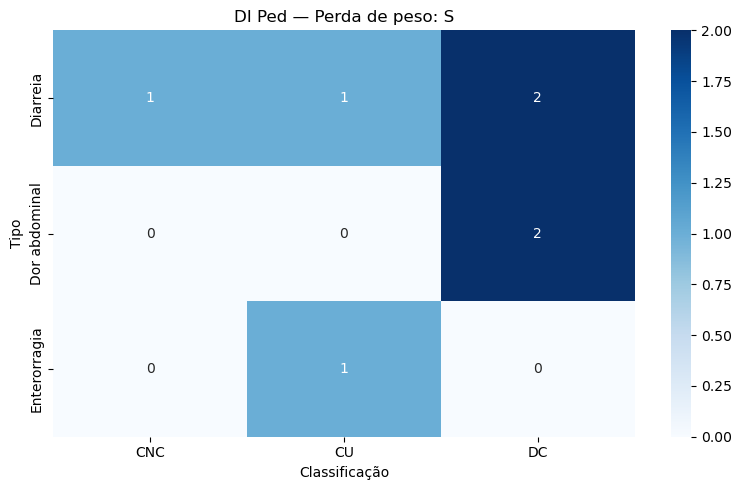

In [30]:
cenario = ct.loc[
    ("DI Ped", slice(None), "S"),
    :
]

cenario.index = cenario.index.droplevel([0, 2])

plt.figure(figsize=(8, 5))

sns.heatmap(
    cenario,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("DI Ped — Perda de peso: S")
plt.xlabel("Classificação")
plt.ylabel("Tipo")

plt.tight_layout()
plt.show()

In [31]:
pd.crosstab(
    [
        mulheres_colunas_categoricas_df["classificacao_idade"],
        mulheres_colunas_categoricas_df["tipo"],
        mulheres_colunas_categoricas_df["perda_peso"]
    ],
    mulheres_colunas_categoricas_df["classificacao"]
)

classificacao                                             CNC  CU  DC
classificacao_idade tipo                      perda_peso             
DI Ped              Diarreia                  N             0   1   3
                                              S             1   1   2
                    Dor abdominal             N             0   1   2
                                              S             0   0   2
                    Enterorragia              S             0   1   0
Início precoce      Diarreia                  N             1   0   0
                                              S             0   2   1
                    Dor abdominal             S             0   0   1
                    Enterorragia              N             1   0   0
                    Febre                     S             0   0   1
VEOIBD              Diarreia                  N             0   0   1
                                              S             0   0   2
                    Enterorragia              N             2   1   0
                                              S             0   1   0
                    Hematoquezia              N             1   0   1
                                              S             0   1   0
                    Perda ponderal            S             0   1   0
VEOIBD              Desaceleração do crescim. N             0   0   1
                    Diarreia                  N             2   0   2
                    Dor abdominal             S             0   1   0
                    Enterorragia              N             1   4   0
                                              S             0   0   1

In [32]:
mulheres_colunas_categoricas_df[mulheres_colunas_categoricas_df['perda_peso'] == 'S']

,classificacao_idade,tipo,perda_peso,classificacao
4,Início precoce,Febre,S,DC
7,DI Ped,Diarreia,S,DC
11,DI Ped,Dor abdominal,S,DC
17,DI Ped,Diarreia,S,CNC
39,VEOIBD,Diarreia,S,DC
40,VEOIBD,Enterorragia,S,CU
45,DI Ped,Diarreia,S,CU
47,VEOIBD,Dor abdominal,S,CU
50,VEOIBD,Diarreia,S,DC
51,VEOIBD,Perda ponderal,S,CU


## Analise Mulheres

## Analise Homens

In [35]:
# homens_df
media2 = homens_df["intervalo_nascimento_sintomas"].mean()
media2

90.01785714285714